In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
d = pd.read_csv('banana_quality_dataset.csv')
d

,sample_id,variety,region,quality_score,quality_category,ripeness_index,ripeness_category,sugar_content_brix,firmness_kgf,length_cm,weight_g,harvest_date,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
0,1,Manzano,Colombia,1.88,Processing,2.11,Turning,16.83,3.53,21.44,146.92,2023-10-16,13.7,58.2,2440.5,183.6
1,2,Plantain,Guatemala,2.42,Processing,4.25,Ripe,16.73,4.09,26.11,160.48,2023-10-14,5.1,280.2,2374.6,109.8
2,3,Burro,Ecuador,3.57,Premium,6.24,Overripe,21.34,1.63,25.20,225.27,2023-09-08,17.7,1246.9,1191.5,147.7
3,4,Manzano,Ecuador,2.21,Processing,5.39,Ripe,16.75,3.31,13.08,137.80,2023-10-07,13.0,1150.2,2845.1,92.8
4,5,Red Dacca,Ecuador,2.35,Processing,5.84,Ripe,16.90,3.07,12.98,227.84,2023-10-02,4.8,526.0,2136.9,129.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Burro,Ecuador,3.50,Good,4.94,Ripe,21.06,2.49,27.95,196.35,2023-10-04,12.4,409.7,2029.9,173.0
996,997,Cavendish,Philippines,2.38,Processing,6.74,Overripe,16.10,2.00,12.39,165.55,2023-09-23,14.0,314.3,1330.7,180.5
997,998,Plantain,Ecuador,1.68,Processing,1.41,Green,17.17,2.28,16.56,210.08,2023-10-19,18.4,683.0,2955.4,189.9
998,999,Fehi,Guatemala,2.02,Processing,1.34,Green,17.03,2.88,26.31,162.50,2023-09-22,8.2,1362.7,1215.8,85.5


In [3]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sample_id           1000 non-null   int64  
 1   variety             1000 non-null   object 
 2   region              1000 non-null   object 
 3   quality_score       1000 non-null   float64
 4   quality_category    1000 non-null   object 
 5   ripeness_index      1000 non-null   float64
 6   ripeness_category   1000 non-null   object 
 7   sugar_content_brix  1000 non-null   float64
 8   firmness_kgf        1000 non-null   float64
 9   length_cm           1000 non-null   float64
 10  weight_g            1000 non-null   float64
 11  harvest_date        1000 non-null   object 
 12  tree_age_years      1000 non-null   float64
 13  altitude_m          1000 non-null   float64
 14  rainfall_mm         1000 non-null   float64
 15  soil_nitrogen_ppm   1000 non-null   float64
dtypes: floa

#### Observations:
* variety, region, quality_score, ripeness_category, harvest_date are the categorical columns.
* 
#### Problem statement:
* Create a Machine Learning Model to predict the Quality of Banana

In [4]:
d.drop(columns = ['sample_id','harvest_date'],inplace = True)

In [5]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   variety             1000 non-null   object 
 1   region              1000 non-null   object 
 2   quality_score       1000 non-null   float64
 3   quality_category    1000 non-null   object 
 4   ripeness_index      1000 non-null   float64
 5   ripeness_category   1000 non-null   object 
 6   sugar_content_brix  1000 non-null   float64
 7   firmness_kgf        1000 non-null   float64
 8   length_cm           1000 non-null   float64
 9   weight_g            1000 non-null   float64
 10  tree_age_years      1000 non-null   float64
 11  altitude_m          1000 non-null   float64
 12  rainfall_mm         1000 non-null   float64
 13  soil_nitrogen_ppm   1000 non-null   float64
dtypes: float64(10), object(4)
memory usage: 109.5+ KB


In [6]:
d.head()

,variety,region,quality_score,quality_category,ripeness_index,ripeness_category,sugar_content_brix,firmness_kgf,length_cm,weight_g,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
0,Manzano,Colombia,1.88,Processing,2.11,Turning,16.83,3.53,21.44,146.92,13.7,58.2,2440.5,183.6
1,Plantain,Guatemala,2.42,Processing,4.25,Ripe,16.73,4.09,26.11,160.48,5.1,280.2,2374.6,109.8
2,Burro,Ecuador,3.57,Premium,6.24,Overripe,21.34,1.63,25.20,225.27,17.7,1246.9,1191.5,147.7
3,Manzano,Ecuador,2.21,Processing,5.39,Ripe,16.75,3.31,13.08,137.80,13.0,1150.2,2845.1,92.8
4,Red Dacca,Ecuador,2.35,Processing,5.84,Ripe,16.90,3.07,12.98,227.84,4.8,526.0,2136.9,129.7


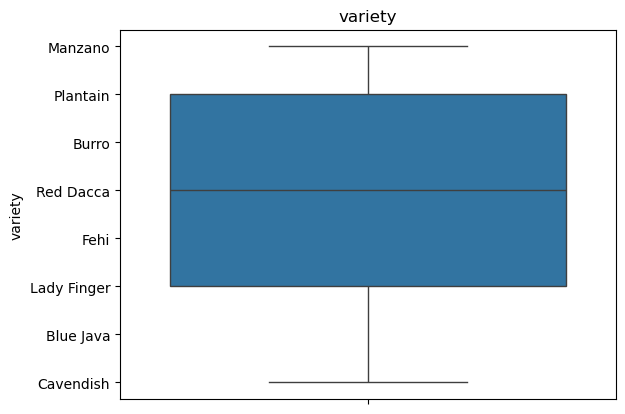

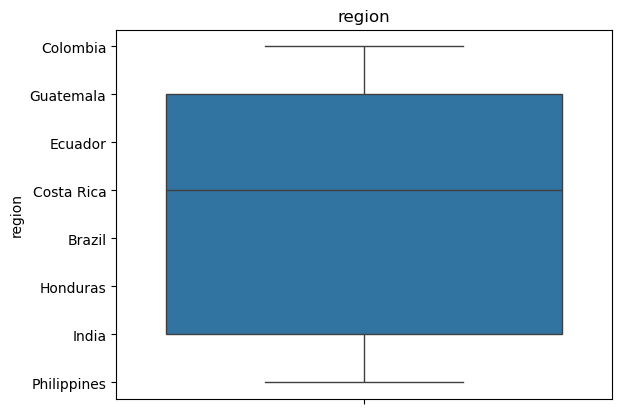

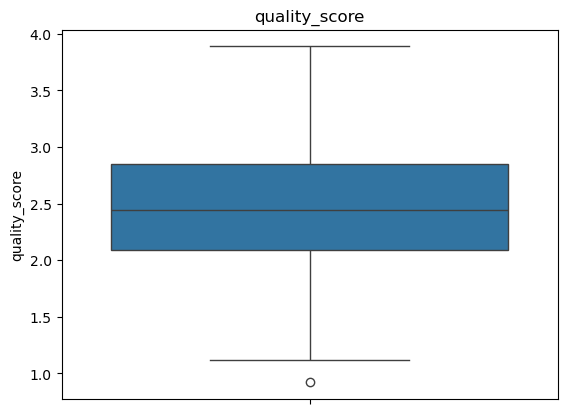

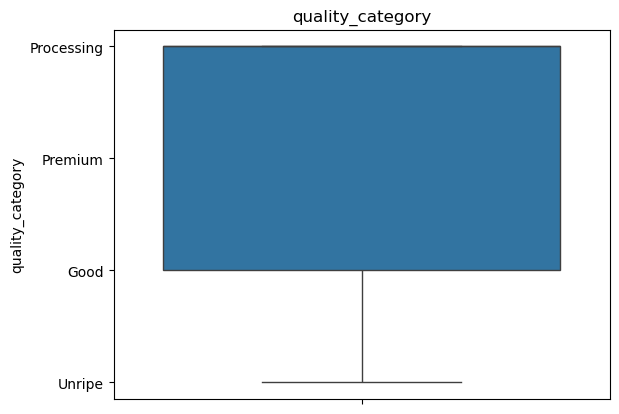

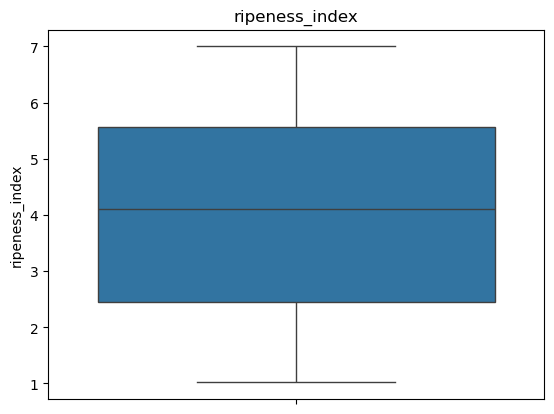

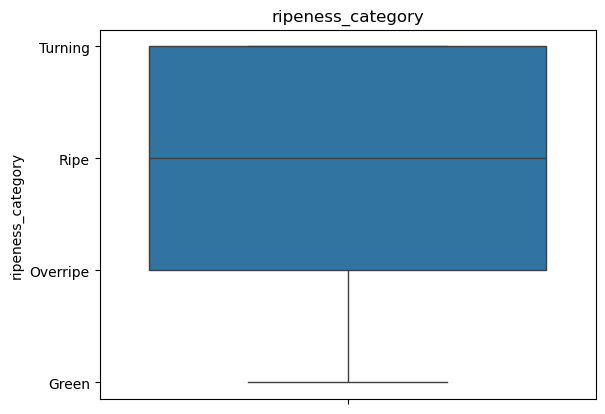

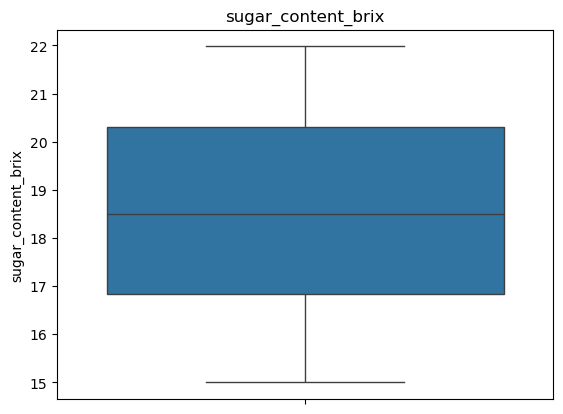

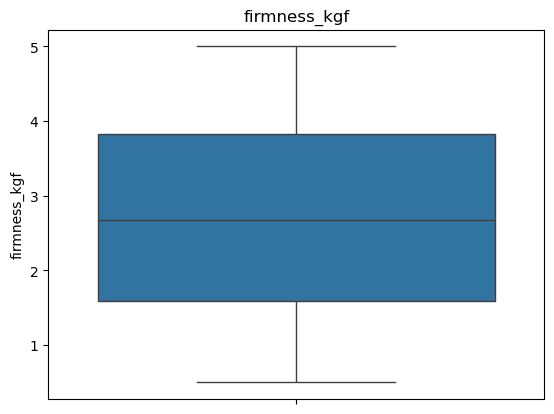

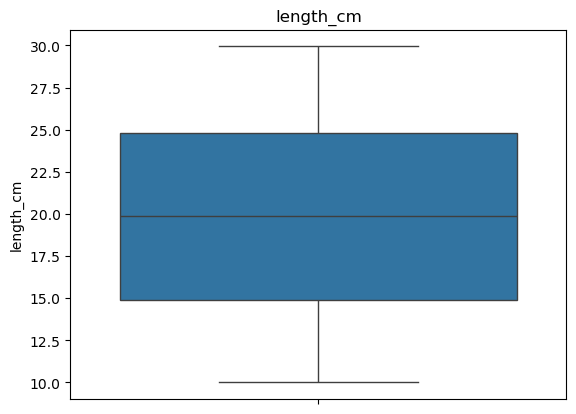

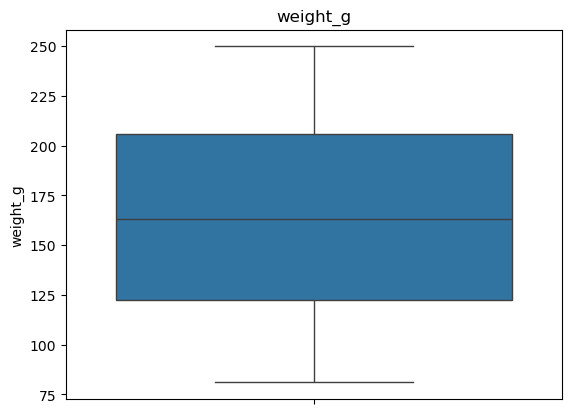

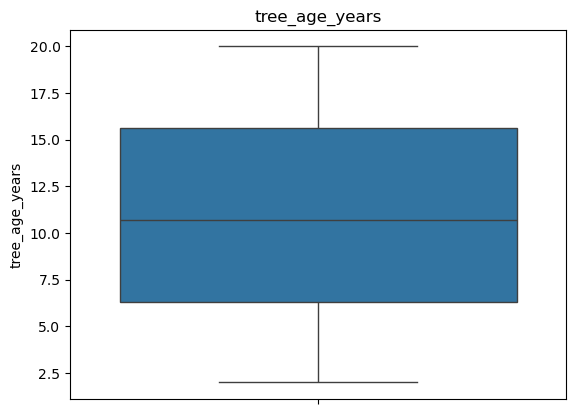

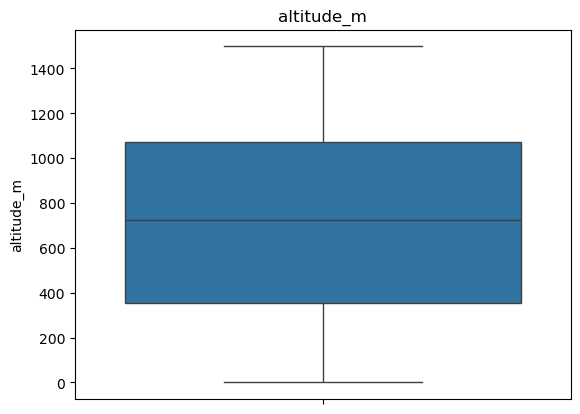

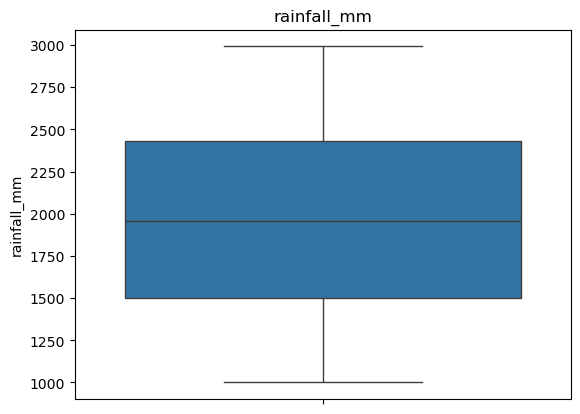

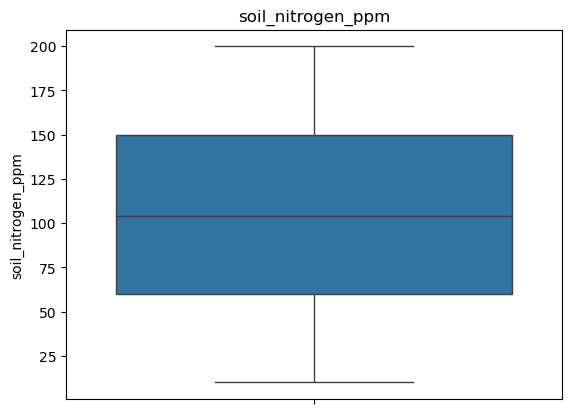

In [7]:
# finding outliers
for i in d.columns:
    sns.boxplot(d[i])
    plt.title(f'{i}')
    plt.show()

In [8]:
# for finding null values
d.isnull().sum()

variety               0
region                0
quality_score         0
quality_category      0
ripeness_index        0
ripeness_category     0
sugar_content_brix    0
firmness_kgf          0
length_cm             0
weight_g              0
tree_age_years        0
altitude_m            0
rainfall_mm           0
soil_nitrogen_ppm     0
dtype: int64

#### Observations:
* In this dataset there is no outliers are there.
* So we can go with *MinMaxScaler*.
#### Note:
* If you want to go with for Regression
* * Target variable will be **quality_score**.
* If you want to go with for Classification.
* * Target variable will be **quality_category**.

In [9]:
# here we have to drop the ripeness_category column
d.drop(columns = 'ripeness_category',inplace = True)

#### Reason:
* in this dataset both 'ripeness_category' and 'ripeness_index' carry same information.
* so we can drop any column b.w these two.

In [10]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   variety             1000 non-null   object 
 1   region              1000 non-null   object 
 2   quality_score       1000 non-null   float64
 3   quality_category    1000 non-null   object 
 4   ripeness_index      1000 non-null   float64
 5   sugar_content_brix  1000 non-null   float64
 6   firmness_kgf        1000 non-null   float64
 7   length_cm           1000 non-null   float64
 8   weight_g            1000 non-null   float64
 9   tree_age_years      1000 non-null   float64
 10  altitude_m          1000 non-null   float64
 11  rainfall_mm         1000 non-null   float64
 12  soil_nitrogen_ppm   1000 non-null   float64
dtypes: float64(10), object(3)
memory usage: 101.7+ KB


## Classification Models:

In [11]:
# here for classification target variable
y = d['quality_category']
# here we have to drop both columns because both columns represents same info
X = d.drop(columns = ['quality_category','quality_score'])

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 11)
(200, 11)
(800,)
(200,)


In [13]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 29 to 102
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   variety             800 non-null    object 
 1   region              800 non-null    object 
 2   ripeness_index      800 non-null    float64
 3   sugar_content_brix  800 non-null    float64
 4   firmness_kgf        800 non-null    float64
 5   length_cm           800 non-null    float64
 6   weight_g            800 non-null    float64
 7   tree_age_years      800 non-null    float64
 8   altitude_m          800 non-null    float64
 9   rainfall_mm         800 non-null    float64
 10  soil_nitrogen_ppm   800 non-null    float64
dtypes: float64(9), object(2)
memory usage: 75.0+ KB


In [14]:
from sklearn.preprocessing import OrdinalEncoder,MinMaxScaler
from sklearn.compose import ColumnTransformer
transformer = ColumnTransformer(transformers = [('t1',OrdinalEncoder(),[0,1]),
                                                ('t2',MinMaxScaler(),[2,3,4,5,6,7,8,9,10])],
                                remainder = 'passthrough')
X_train_trans = transformer.fit_transform(X_train)
X_test_trans = transformer.transform(X_test)

print(X_train_trans.shape)
print(X_test_trans.shape)
                                                

(800, 11)
(200, 11)


In [15]:
X_train_trans = pd.DataFrame(X_train_trans,columns = X_train.columns)
X_train_trans.head()

,variety,region,ripeness_index,sugar_content_brix,firmness_kgf,length_cm,weight_g,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
0,6.0,2.0,0.827759,0.656609,0.632517,0.362130,0.115909,0.100000,0.152136,0.809289,0.426014
1,0.0,7.0,0.118729,0.837644,0.126949,0.590658,0.098792,0.250000,0.701936,0.325031,0.441285
2,6.0,5.0,0.065217,0.520115,0.028953,0.883978,0.305378,0.738889,0.678772,0.608084,0.552396
3,0.0,6.0,0.409699,0.300287,0.487751,0.682069,0.734778,0.055556,0.508278,0.595983,0.505003
4,7.0,1.0,0.125418,0.997126,0.933185,0.379206,0.886461,0.366667,0.606208,0.504946,0.890469


In [16]:
X_test_trans = pd.DataFrame(X_test_trans,columns = X_test.columns)
X_test_trans.head()

,variety,region,ripeness_index,sugar_content_brix,firmness_kgf,length_cm,weight_g,tree_age_years,altitude_m,rainfall_mm,soil_nitrogen_ppm
0,5.0,3.0,0.934783,0.133621,0.467706,0.579608,0.575101,0.211111,0.506208,0.425960,0.610848
1,1.0,4.0,0.192308,0.545977,0.750557,0.350578,0.261727,0.005556,0.208678,0.080090,0.018431
2,5.0,5.0,0.827759,0.366379,0.904232,0.721748,0.890903,0.172222,0.604272,0.601657,0.009479
3,3.0,6.0,0.598662,0.474138,0.507795,0.513310,0.179164,0.572222,0.038117,0.435300,0.560295
4,3.0,7.0,0.108696,0.139368,0.129176,0.004018,0.269131,0.350000,0.446996,0.984584,0.671406


## Classification Models:

### 1. KNN Classification Model

In [17]:
# let us build a classification model
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_trans,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
# let us prediction using test data
y_pred = knn_model.predict(X_test_trans)

In [19]:
# let us validate the model we need metrics so we are using accuracy score
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.645

In [20]:
# accuracy score 
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.645

In [21]:
d['quality_category'].value_counts()

quality_category
Processing    506
Good          434
Unripe         35
Premium        25
Name: count, dtype: int64

#### Observation:
* here the value counts are not equal so it is unbalanced data
* so for unbalanced data accuracy score is not suitable

In [22]:
from sklearn.metrics import confusion_matrix,classification_report

y_true = [1,0,1,1,0,1,0] # actual output
y_pred2 = [1,0,1,0,0,1,1] # predicted output

# confusion matrix
cm = confusion_matrix(y_true,y_pred2)
cm

array([[2, 1],
       [1, 3]])

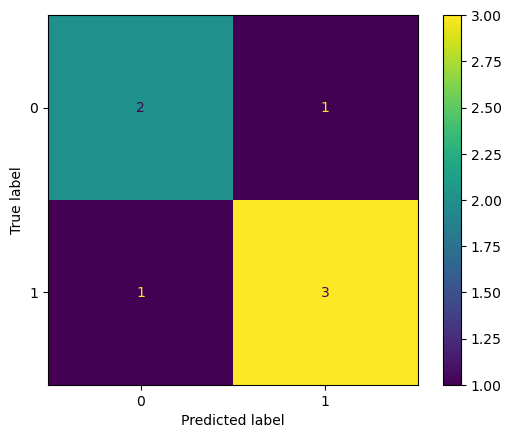

In [23]:
# confusion matrix display
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_true,y_pred2)
plt.show()

In [24]:
classification_report(y_true,y_pred2)

'              precision    recall  f1-score   support\n\n           0       0.67      0.67      0.67         3\n           1       0.75      0.75      0.75         4\n\n    accuracy                           0.71         7\n   macro avg       0.71      0.71      0.71         7\nweighted avg       0.71      0.71      0.71         7\n'

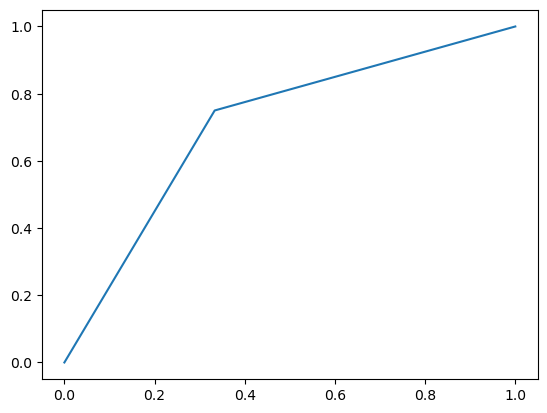

In [25]:
# ROC
from sklearn.metrics import roc_curve
# calculate the ROC curve
fpr1,tpr1,thresholds = roc_curve(y_true,y_pred2)
# plot the ROC curve
plt.plot(fpr1,tpr1)

In [26]:
# AUC
from sklearn.metrics import auc
auc_score = auc(fpr1,tpr1)
auc_score

0.7083333333333334

In [27]:
# AUC
from sklearn.metrics import roc_auc_score
roc_auc_score = roc_auc_score(y_true,y_pred2,multi_class ='ovr')
roc_auc_score

0.7083333333333334

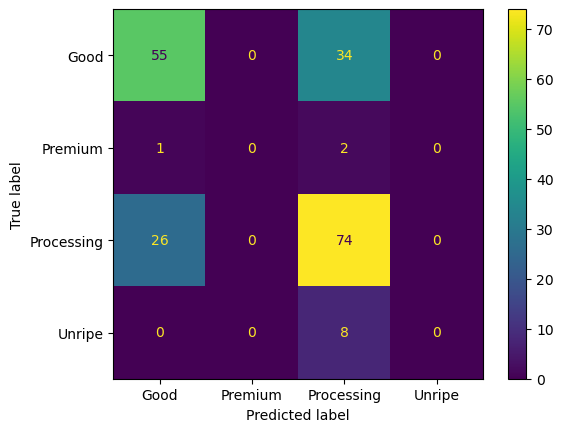

In [28]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()

In [31]:
# classification report
cr = classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

        Good       0.67      0.62      0.64        89
     Premium       0.00      0.00      0.00         3
  Processing       0.63      0.74      0.68       100
      Unripe       0.00      0.00      0.00         8

    accuracy                           0.65       200
   macro avg       0.32      0.34      0.33       200
weighted avg       0.61      0.65      0.63       200



C:\Users\kvsvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kvsvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\kvsvi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
# ROC 
from sklearn.metrics import roc_curve
fpr,tpr,thresholds = roc_curve(y_test,y_pred)
plt.plot(fpr,tpr)

ValueError: multiclass format is not supported

#### Tuning using GridSearchCV:

In [32]:
# Hyper parameteric Tuning
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier

In [34]:
tuned_parameters = [{'n_neighbors': [i for i in range(1,51)],
                      'p':[1,2,3]}]
clf = GridSearchCV(estimator = KNeighborsClassifier(),
                   param_grid = tuned_parameters,
                   scoring = 'accuracy',
                   cv = 5,
                   return_train_score = True,
                   verbose = 1)
clf.fit(X_train_trans,y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


,estimator,KNeighborsClassifier()
,param_grid,"[{'n_neighbors': [1, 2, ...], 'p': [1, 2, ...]}]"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_neighbors,25


In [39]:
print('Best parameters')
print(clf.best_params_)
print(clf.best_estimator_)
print('Score on Test Data:',clf.score(X_test_trans,y_test))

Best parameters
{'n_neighbors': 25, 'p': 1}
KNeighborsClassifier(n_neighbors=25, p=1)
Score on Test Data: 0.715


In [37]:
knn = KNeighborsClassifier(n_neighbors = 25,p = 1)
knn.fit(X_train_trans,y_train)

,n_neighbors,25
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [38]:
y_pred = knn.predict(X_test_trans)
accuracy_score(y_test,y_pred)

0.715

#### RandomizedSearchCV:

In [ ]:
tuned_parameters = [{'n_neighbors':[i for i in range(1,51)],
                    'p':[1,2,3]}]
clf = RandomizedSearchCV(estimator = KNeighborsClassifier(),
                         param_distributions = tuned_parameters,
                         scoring = 'accuracy',
                         cv = 5,
                         return_train_score = True,
                         verbose = 1)
clf.fit(